# Computer Vision AI-605

# Fourier Transformation

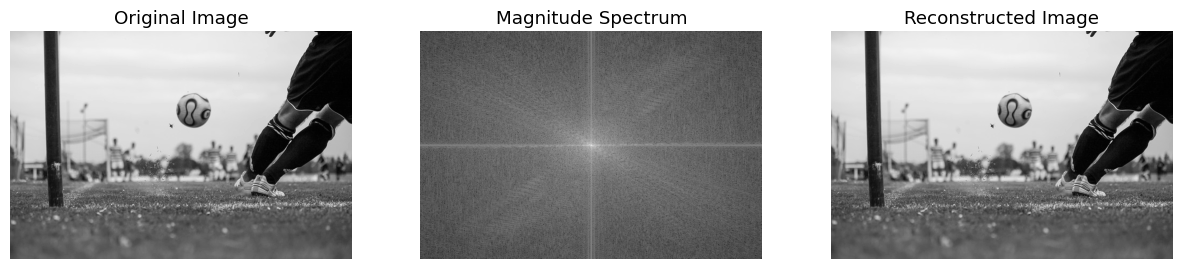

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
image = cv2.imread('input_image.jpg', 0)

dft = np.fft.fft2(image)  
dft_shifted = np.fft.fftshift(dft)  

magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)  

dft_ishifted = np.fft.ifftshift(dft_shifted)  
img_back = np.fft.ifft2(dft_ishifted)  
img_back = np.abs(img_back) 

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Magnitude Spectrum
plt.subplot(1, 3, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

# Reconstructed Image (Inverse Fourier)
plt.subplot(1, 3, 3)
plt.imshow(img_back, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

plt.show()

## Edge Detection Using Sobel, Laplace, Canny

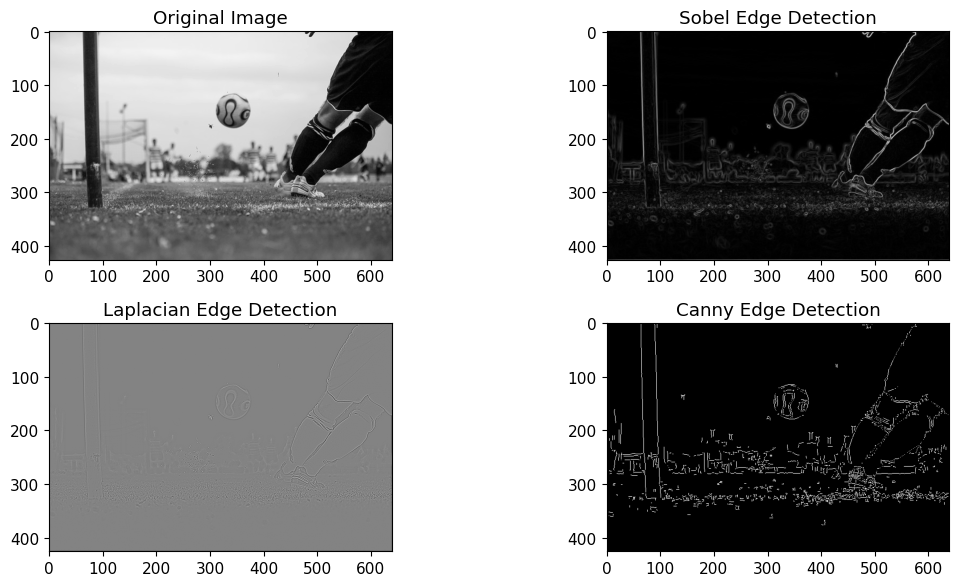

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
image = cv2.imread('./input_image.jpg', cv2.IMREAD_GRAYSCALE)

# Define a helper function to apply convolution
def convolve(image, kernel):
    # Get image dimensions
    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape
    
    # Define output dimensions and initialize output array
    output = np.zeros((image_h, image_w), dtype=np.float64)
    
    # Pad the image to apply the kernel at the borders
    padded_image = np.pad(image, ((kernel_h // 2, kernel_h // 2), (kernel_w // 2, kernel_w // 2)), mode='constant')
    
    # Perform convolution
    for i in range(image_h):
        for j in range(image_w):
            region = padded_image[i:i + kernel_h, j:j + kernel_w]
            output[i, j] = np.sum(region * kernel)
    
    return output

# 1. Sobel Edge Detection 

sobel_x_kernel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float64)
sobel_y_kernel = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float64)

# Apply convolution with Sobel kernels
sobel_x = convolve(image, sobel_x_kernel)
sobel_y = convolve(image, sobel_y_kernel)

# Calculate the gradient magnitude
sobel_edge = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

# 2. Laplacian Edge Detection 
laplacian_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)
laplacian_edge = convolve(image, laplacian_kernel)

# 3. Canny Edge Detection 
# Step 1: Gaussian blur to reduce noise
gaussian_kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float64) / 16
smoothed_image = convolve(image, gaussian_kernel)

# Step 2: Gradient calculation (using Sobel filters)
canny_x = convolve(smoothed_image, sobel_x_kernel)
canny_y = convolve(smoothed_image, sobel_y_kernel)
canny_gradient = np.sqrt(canny_x ** 2 + canny_y ** 2)
canny_direction = np.arctan2(canny_y, canny_x)

# Step 3: Non-maximum suppression
def non_maximum_suppression(gradient, direction):
    output = np.zeros(gradient.shape, dtype=np.float64)
    angle = direction * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, gradient.shape[0] - 1):
        for j in range(1, gradient.shape[1] - 1):
            try:
                q = 255
                r = 255
                # Angle 0
                if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                    q = gradient[i, j + 1]
                    r = gradient[i, j - 1]
                # Angle 45
                elif 22.5 <= angle[i, j] < 67.5:
                    q = gradient[i + 1, j - 1]
                    r = gradient[i - 1, j + 1]
                # Angle 90
                elif 67.5 <= angle[i, j] < 112.5:
                    q = gradient[i + 1, j]
                    r = gradient[i - 1, j]
                # Angle 135
                elif 112.5 <= angle[i, j] < 157.5:
                    q = gradient[i - 1, j - 1]
                    r = gradient[i + 1, j + 1]

                if (gradient[i, j] >= q) and (gradient[i, j] >= r):
                    output[i, j] = gradient[i, j]
                else:
                    output[i, j] = 0

            except IndexError as e:
                pass
    return output

# Step 3 continued: Non-maximum suppression
canny_non_max = non_maximum_suppression(canny_gradient, canny_direction)

# Step 4: Double thresholding
high_threshold = canny_non_max.max() * 0.2
low_threshold = high_threshold * 0.5
canny_edge = np.zeros_like(canny_non_max)

# Strong edges
strong_i, strong_j = np.where(canny_non_max >= high_threshold)
canny_edge[strong_i, strong_j] = 255

# Weak edges
weak_i, weak_j = np.where((canny_non_max >= low_threshold) & (canny_non_max < high_threshold))
canny_edge[weak_i, weak_j] = 75

# Finalize Canny by edge tracking by hysteresis
for i in range(1, canny_edge.shape[0] - 1):
    for j in range(1, canny_edge.shape[1] - 1):
        if canny_edge[i, j] == 75:
            if 255 in [canny_edge[i + 1, j - 1], canny_edge[i + 1, j], canny_edge[i + 1, j + 1], canny_edge[i, j - 1], 
                       canny_edge[i, j + 1], canny_edge[i - 1, j - 1], canny_edge[i - 1, j], canny_edge[i - 1, j + 1]]:
                canny_edge[i, j] = 255
            else:
                canny_edge[i, j] = 0

# Plot the results
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(2, 2, 2)
plt.imshow(sobel_edge, cmap='gray')
plt.title('Sobel Edge Detection')

plt.subplot(2, 2, 3)
plt.imshow(laplacian_edge, cmap='gray')
plt.title('Laplacian Edge Detection')

plt.subplot(2, 2, 4)
plt.imshow(canny_edge, cmap='gray')
plt.title('Canny Edge Detection')

plt.tight_layout()
plt.show()


# Applying Gradient

G_x (Horizontal Gradient):
 [[          0          20           0         -20           0]
 [          0          40           0         -40           0]
 [          0          60           0         -60           0]
 [          0          40           0         -40           0]
 [          0          20           0         -20           0]]
G_y (Vertical Gradient):
 [[          0           0           0           0           0]
 [         20          40          60          40          20]
 [          0           0           0           0           0]
 [        -20         -40         -60         -40         -20]
 [          0           0           0           0           0]]
Gradient Magnitude:
 [[          0          20           0          20           0]
 [         20      56.569          60      56.569          20]
 [          0          60           0          60           0]
 [         20      56.569          60      56.569          20]
 [          0          20           0    

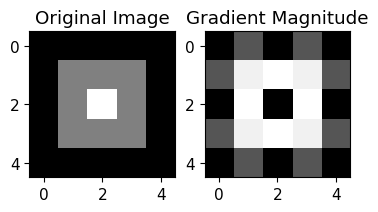

In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = np.array([[10, 10, 10, 10, 10],
                  [10, 20, 20, 20, 10],
                  [10, 20, 30, 20, 10],
                  [10, 20, 20, 20, 10],
                  [10, 10, 10, 10, 10]], dtype=np.float32)

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

G_x = cv2.filter2D(image, -1, sobel_x)
G_y = cv2.filter2D(image, -1, sobel_y)

gradient_magnitude = np.sqrt(G_x**2 + G_y**2)

print("G_x (Horizontal Gradient):\n", G_x)
print("G_y (Vertical Gradient):\n", G_y)
print("Gradient Magnitude:\n", gradient_magnitude)

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Gradient Magnitude")
plt.imshow(gradient_magnitude, cmap='gray')

plt.show()


## Object Detection using NN

Using cache found in C:\Users\vasil/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2024-11-8 Python-3.12.5 torch-2.5.1+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
C:\Users\vasil/.cache\torch\hub\ultralytics_yolov5_master\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


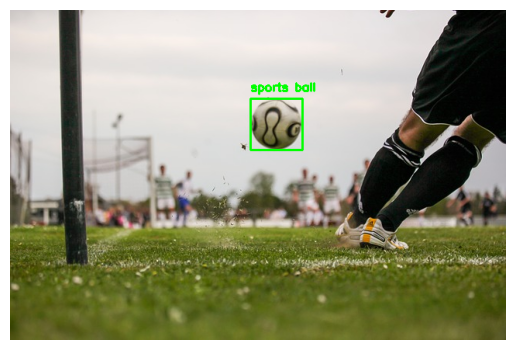

In [18]:
import torch
import cv2

%matplotlib inline
import matplotlib.pyplot as plt


image_path = './input_image.jpg'
image = cv2.imread(image_path)


model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

results = model(image)

detections = results.pandas().xyxy[0]  

ball_detections = detections[detections['name'] == 'sports ball']

for index, row in ball_detections.iterrows():
    x1, y1, x2, y2 = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(image, row['name'], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Show image with bounding box
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show(block=True)
